# GROUP 4 - MIDTERM PROJECT

## Team Members
- ##### Rodney Hong (Team Manager)
- ##### Vishnu Sainadh Kedarisetty
- ##### Hassan Ali Khan

# 1. Introduction

## Title - NCES CCD School Data - California Public Schools


## Problem statement - 
- ##### Point 1. 
- ##### Point 2.

**Source:** [NCES Common Core of Data (CCD) School Search](https://nces.ed.gov/ccd/schoolsearch/)

**Legality:**
- `.gov` U.S. Government website — public domain data
- `robots.txt` does NOT block `/ccd/schoolsearch/`
- No API used — pure HTML scraping

## Objectives - 

- ##### Import libraries for data handling, visualization, and text analysis (pandas, numpy, matplotlib/seaborn/plotly, scikit-learn, nltk/spaCy).
- ##### Document the scraping process and describe the raw schools_deatiled.csv (columns, sample rows, data types, scraping caveats).
- ##### Load the dataset reproducibly and verify encoding/delimiters.
- ##### EDA — basic exploration: shape, dtypes, non-null counts, summary statistics, and sample records.
- ##### EDA — univariate/bivariate/multivariate: distributions, skewness, correlations, pairwise relationships.
- ##### Data cleaning & transforms: parse prices/dates, remove special chars, convert types, impute missing values, remove duplicates, handle outliers, create derived features.
- ##### Visualizations: clear univariate, bivariate, and multivariate plots (histograms, boxplots, scatter, heatmaps); use interactive plots where useful.
- ##### Data mining: formulate and answer ≥10 focused questions (e.g., pricing by category/brand, rating vs reviews, seller comparisons, outlier detection, sentiment vs rating, clustering).
- ##### Conclusion: produce ≥20 concise insights and at least 3 actionable recommendations.

# 2. Import Libraries

In [1]:
# general libraries
import pandas as pd
import numpy as np
import time
import re
import os
import json
from datetime import datetime

# data scraping libraries
import requests
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed

# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# suppressing the warnings
import warnings
warnings.filterwarnings('ignore')

**Observations:**

The code imports essential Python libraries that are frequently used for efficient data scraping, analysis and visualization.

The general libraries such as `pandas`, `numpy`, `time`, `re`, `os`, and `json` support data handling, delay management, pattern matching, and file operations. The `datetime` module is used for tracking timestamps during execution.

The data scraping process is enabled by `requests` and `BeautifulSoup`, which are responsible for fetching and parsing web content. The use of `ThreadPoolExecutor` allows concurrent execution, improving the speed and efficiency of large-scale data collection.

Visualization libraries such as `matplotlib` and `seaborn` provide the tools required to create graphical representations of the data in later stages.

# 3. Data Scraping

## 3.1 Data Scraping - Configuration & Constants

In [ ]:
# === Configuration Constants ===

# Base URL for the NCES CCD School Search website
BASE_URL = "https://nces.ed.gov/ccd/schoolsearch/"

# URL endpoints for search results and detail pages
SEARCH_URL = BASE_URL + "school_list.asp"
DETAIL_URL = BASE_URL + "school_detail.asp"

# State code for California (FIPS code)
STATE_CODE = "06"
STATE_NAME = "California"

# Polite scraping delay (seconds between requests)
DELAY = 1.0

# Maximum retry attempts for failed requests
MAX_RETRIES = 3

# Checkpoint file to enable resume after interruption
CHECKPOINT_FILE = "phase2_checkpoint.json"

# Output CSV file path
OUTPUT_FILE = "schools_detailed.csv"

# Concurrent Scraping Settings
MAX_WORKERS = 30     # safe range: 20–50
BATCH_SIZE = 100     # checkpoint frequency

# HTTP headers to identify ourselves as an academic research project
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Academic Research Project - NCES CCD Data Collection)"
}

# Print configuration summary
print("=" * 50)
print("SCRAPER CONFIGURATION")
print("=" * 50)
print(f"Target State:      {STATE_NAME} (Code: {STATE_CODE})")
print(f"Request Delay:     {DELAY} seconds")
print(f"Max Retries:       {MAX_RETRIES}")
print(f"Checkpoint File:   {CHECKPOINT_FILE}")
print(f"Output CSV:        {OUTPUT_FILE}")
print(f"Base URL:          {BASE_URL}")
print("=" * 50)

**Observations:**

The code defines the configuration settings required for controlling the web scraping process.

The base URLs and endpoints are set to target the NCES CCD School Search system, specifically focusing on schools in California using the state code. Scraping parameters such as request delay and maximum retries are defined to ensure stable and polite interaction with the website.

File-related configurations, including the checkpoint file and output CSV, enable data persistence and allow the scraping process to resume in case of interruptions. The inclusion of concurrency settings such as maximum workers and batch size indicates an optimized approach for handling large-scale data collection.

Additionally, custom HTTP headers are defined to identify the scraping activity as part of an academic research project. The printed configuration summary provides a clear overview of all settings, confirming that the scraper is properly configured before execution.

## 3.2 Data Scraping Functions

### 3.2.1 Helper Function - Fetch a Web Page with Retry Logic

In [ ]:
def fetch_page(url, params=None):
    """
    Fetch a web page with retry logic and polite delays.
    
    Parameters:
        url (str): The URL to fetch
        params (dict): Optional query parameters
    
    Returns:
        str: HTML content of the page, or None if all retries fail
    """
    for attempt in range(MAX_RETRIES):
        try:
            # Polite delay before each request
            time.sleep(DELAY)
            
            # Send GET request with timeout
            response = requests.get(url, params=params, headers=HEADERS, timeout=30)
            response.raise_for_status()  # Raise exception for HTTP errors
            
            return response.text
            
        except requests.RequestException as e:
            # Log the failure and retry with exponential backoff
            wait_time = DELAY * (attempt + 1) * 2
            print(f"  [RETRY {attempt + 1}/{MAX_RETRIES}] Error: {e}. Waiting {wait_time}s...")
            if attempt < MAX_RETRIES - 1:
                time.sleep(wait_time)
            else:
                print(f"  [FAILED] Could not fetch: {url}")
                return None

# Quick test: fetch the first search results page
print("Testing fetch_page function...")
test_html = fetch_page(SEARCH_URL, {'Search': 1, 'State': STATE_CODE, 'SchoolPageNum': 1})
print(f"Fetched {len(test_html)} characters" if test_html else "FAILED!")

**Observations:**

The code defines a helper function to fetch web pages with retry logic and controlled delays.

The function ensures stable data retrieval by introducing a delay between requests and handling potential network or server errors using multiple retry attempts. In case of failures, an exponential backoff strategy is applied to reduce request frequency and improve the chances of success.

The use of HTTP headers and timeout settings further enhances reliability and prevents the program from hanging during requests. The function returns the HTML content when successful, or `None` if all retry attempts fail.

The test execution confirms that the function is working correctly by successfully fetching content from the target website, indicating that the scraping process can proceed reliably.

### 3.2.2 Parser Function - Search Results Page

In [ ]:
def parse_search_page(html_content):
    """
    Parse a search results page to extract school basic info and detail URLs.
    
    The NCES search results use <div class='resultRow'> elements (not tables).
    Each row contains 6 <div> children: [number, name+address, phone, county, students, grades]
    
    Parameters:
        html_content (str): Raw HTML of the search results page
    
    Returns:
        list[dict]: List of school dictionaries with basic info
    """
    soup = BeautifulSoup(html_content, 'html.parser')
    schools = []
    
    # Each school entry is a <div class='resultRow'>
    result_rows = soup.find_all('div', class_='resultRow')
    
    for row in result_rows:
        try:
            # Get the 6 child <div> elements
            divs = row.find_all('div', recursive=False)
            if len(divs) < 5:
                continue
            
            # Column 1 (index 1): School name link + address
            link = divs[1].find('a')
            if not link:
                continue
            
            school_name = link.get_text(strip=True)
            detail_href = link.get('href', '')
            
            # Extract school ID from the detail URL
            id_match = re.search(r'ID=(\d+)', detail_href)
            school_id = id_match.group(1) if id_match else ''
            
            # Extract address from <span> below the link
            addr_span = divs[1].find('span')
            address = addr_span.get_text(strip=True) if addr_span else ''
            
            # Parse city, state, zip from address string
            city, state, zip_code = '', 'CA', ''
            addr_match = re.match(r'(.+),\s*([A-Z]{2})\s*(\d{5}(?:-\d+)?)', address)
            if addr_match:
                # Address format: "Street, City, ST ZIPCODE"
                full_addr = addr_match.group(0)
                zip_code = addr_match.group(3)
                state = addr_match.group(2)
                # Extract city (last part before state)
                parts = address.rsplit(',', 2)
                if len(parts) >= 2:
                    city = parts[-2].strip()
                    street = ','.join(parts[:-2]).strip()
                else:
                    city = ''
                    street = address
            else:
                street = address
            
            # Columns 2-5: Phone, County, Students, Grades
            phone = divs[2].get_text(strip=True) if len(divs) > 2 else ''
            county = divs[3].get_text(strip=True) if len(divs) > 3 else ''
            total_students = divs[4].get_text(strip=True) if len(divs) > 4 else ''
            grades = divs[5].get_text(strip=True) if len(divs) > 5 else ''
            
            # Build the full source URL for backtracking
            source_url = BASE_URL + detail_href
            
            schools.append({
                'school_id': school_id,
                'school_name': school_name,
                'street_address': street if 'street' in dir() else address,
                'city': city,
                'state': state,
                'zip_code': zip_code,
                'phone': phone,
                'county': county,
                'total_students_listing': total_students,
                'grades_listing': grades,
                'detail_href': detail_href,
                'source_url': source_url
            })
            
        except Exception as e:
            print(f"  [WARNING] Error parsing a school entry: {e}")
            continue
    
    return schools

print("parse_search_page() function defined successfully.")

**Observations:** 

The code defines a function to parse the search results page and extract basic information for each school.

The function uses `BeautifulSoup` to navigate the HTML structure and identify individual school entries based on the `resultRow` class. For each entry, it extracts key attributes such as school name, school ID, address, phone number, county, total students, and grade levels.

Regular expressions are used to accurately extract structured components like school ID and address details, including city, state, and zip code. The function also constructs a source URL for each school, enabling access to detailed information in later stages.

Error handling is included to ensure that the parsing process continues even if individual entries fail. Overall, the function successfully transforms raw HTML content into a structured list of dictionaries, making the data ready for further processing.

#### 3.2.2.1 Test - Parse First Search Results Page

In [ ]:
# Test the search page parser on the first page of California results
test_schools = parse_search_page(test_html)

print(f"Schools parsed from page 1: {len(test_schools)}")
print("\nFirst 2 schools:")
print("-" * 120)
for i, school in enumerate(test_schools[:2], 1):
    print(f"  {i}. {school['school_name']}")
    print(f"     ID: {school['school_id']}")
    print(f"     Address: {school['street_address']}")
    print(f"     City: {school['city']}, {school['state']} {school['zip_code']}")
    print(f"     County: {school['county']}")
    print(f"     Students: {school['total_students_listing']}")
    print(f"     Grades: {school['grades_listing']}")
    print(f"     Source URL: {school['source_url']}")
    print()

**Observations:** 

The code tests the search page parser by applying it to the first page of the California school results.

The output shows that a total of 15 schools were successfully extracted from the page (as expected from the website's pagination), indicating that the parser is correctly identifying and processing all available entries. A sample of the first two schools is displayed, confirming that key attributes such as school name, ID, address, city, county, student count, and grade levels are being accurately extracted.

The presence of valid source URLs for each school further confirms that the links to detailed pages are correctly constructed. Overall, the results validate that the parsing function is working as expected and is ready to be used for large-scale data extraction across multiple pages.

### 3.2.3 Parser Function - School Detail Page

In [ ]:
def parse_detail_page(html_content):
    """
    Parse a school detail page to extract all data fields.
    
    The detail page uses two patterns for key-value data:
    1. Directory Info: <div class='formCol'> containing <span><b>Label:</b></span> + value
    2. School Details: <span><b>Label:</b> value</span>
    
    Demographics are in HTML tables with colored cells.
    
    Parameters:
        html_content (str): Raw HTML of the detail page
    
    Returns:
        dict: Dictionary of parsed data fields
    """
    soup = BeautifulSoup(html_content, 'html.parser')
    data = {}
    
    # --- Helper: Extract value from a <div class='formCol'> containing the label ---
    def get_formcol_value(label_text):
        """For directory info fields where label and value are in a formCol div."""
        try:
            b_tag = soup.find('b', string=label_text)
            if b_tag:
                # Navigate to the parent div.formCol
                form_col = b_tag.find_parent('div', class_='formCol')
                if form_col:
                    # Get all text in the div, remove the label
                    full_text = form_col.get_text(separator='|', strip=True)
                    # Check for <a> tag (e.g., District Name links)
                    link = form_col.find('a')
                    if link and label_text in ['District Name:']:
                        return link.get_text(strip=True)
                    # Remove the label from the full text
                    parts = full_text.split('|')
                    # Value is after the label
                    for i, part in enumerate(parts):
                        if label_text.rstrip(':') in part:
                            if i + 1 < len(parts):
                                return parts[i + 1].strip()
                    # Fallback: get text after removing label
                    clean = full_text.replace(label_text, '').strip().strip('|').strip()
                    return clean if clean else None
        except Exception:
            pass
        return None
    
    # --- Helper: Extract value from <span><b>Label:</b> VALUE</span> ---
    def get_span_value(label_text):
        """For school detail fields where value is in the same span as the label."""
        try:
            b_tag = soup.find('b', string=label_text)
            if b_tag:
                parent_span = b_tag.parent
                full_text = parent_span.get_text(strip=True)
                # Remove the label to get just the value
                value = full_text.replace(label_text, '').strip()
                # Also check for link inside span
                if not value:
                    link = parent_span.find('a')
                    if link:
                        return link.get_text(strip=True)
                return value if value else None
        except Exception:
            pass
        return None
    
    # --- Extract Directory Information ---
    data['nces_school_id'] = get_formcol_value('NCES School ID:')
    data['district_name'] = get_formcol_value('District Name:')
    data['school_type'] = get_formcol_value('Type:')
    data['charter_school'] = get_formcol_value('Charter:')
    
    # Grade Span: may be in formCol or span + additional span
    gs = get_formcol_value('Grade Span:')
    if gs:
        # Clean up: may contain extra text from grade visualization table
        gs_clean = gs.split('|')[0].strip() if '|' in gs else gs.strip()
        parts = gs_clean.split('-')
        data['low_grade'] = parts[0].strip() if len(parts) >= 1 else None
        data['high_grade'] = parts[-1].strip() if len(parts) >= 2 else parts[0].strip()
    else:
        data['low_grade'] = None
        data['high_grade'] = None
    
    # --- Extract School Details (span-based) ---
    data['locale'] = get_span_value('Locale:')
    
    # County: value is inside a link within the span
    county_b = soup.find('b', string='County:')
    if county_b:
        county_span = county_b.parent
        county_link = county_span.find('a')
        data['county_detail'] = county_link.get_text(strip=True) if county_link else get_span_value('County:')
    else:
        data['county_detail'] = None
    
    # Numeric school details
    ts = get_span_value('Total Students:')
    data['total_students_detail'] = ts.replace(',', '') if ts else None
    
    tf = get_span_value('Classroom Teachers (FTE):')
    data['total_teachers_fte'] = tf if tf else None
    
    sr = get_span_value('Student/Teacher Ratio:')
    data['student_teacher_ratio'] = sr if sr else None
    
    # --- Extract Free/Reduced Lunch (contains <sup> tags) ---
    def get_lunch_value(partial_label):
        """Extract lunch eligibility count — label contains superscript footnotes."""
        try:
            for b_tag in soup.find_all('b'):
                if partial_label.lower() in b_tag.get_text().lower():
                    parent = b_tag.parent
                    text = parent.get_text(strip=True)
                    # Extract number after the colon
                    m = re.search(r':\s*([\d,]+)', text)
                    if m:
                        return m.group(1).replace(',', '')
        except Exception:
            pass
        return None
    
    data['free_lunch_eligible'] = get_lunch_value('Free lunch eligible')
    data['reduced_lunch_eligible'] = get_lunch_value('Reduced-price lunch eligible')
    
    # --- Extract Gender Demographics (from table with Male/Female headers) ---
    data['male_students'] = None
    data['female_students'] = None
    
    tables = soup.find_all('table')
    for table in tables:
        first_row = table.find('tr')
        if first_row and 'Male' in first_row.get_text() and 'Female' in first_row.get_text():
            all_rows = table.find_all('tr')
            if len(all_rows) >= 2:
                cells = all_rows[1].find_all('td')
                if len(cells) >= 3:
                    data['male_students'] = cells[1].get_text(strip=True).replace(',', '')
                    data['female_students'] = cells[2].get_text(strip=True).replace(',', '')
            break
    
    # --- Extract Race/Ethnicity Demographics (from table with American Indian header) ---
    race_keys = ['american_indian', 'asian', 'black', 'hispanic', 'white', 'hawaiian_pi', 'two_or_more']
    for key in race_keys:
        data[key] = None
    
    for table in tables:
        first_row = table.find('tr')
        if first_row and 'American Indian' in first_row.get_text():
            all_rows = table.find_all('tr')
            if len(all_rows) >= 2:
                cells = all_rows[1].find_all('td')
                if len(cells) >= 8:
                    data['american_indian'] = cells[1].get_text(strip=True).replace(',', '')
                    data['asian'] = cells[2].get_text(strip=True).replace(',', '')
                    data['black'] = cells[3].get_text(strip=True).replace(',', '')
                    data['hispanic'] = cells[4].get_text(strip=True).replace(',', '')
                    data['white'] = cells[5].get_text(strip=True).replace(',', '')
                    data['hawaiian_pi'] = cells[6].get_text(strip=True).replace(',', '')
                    data['two_or_more'] = cells[7].get_text(strip=True).replace(',', '')
            break
    
    return data

print("parse_detail_page() function defined successfully.")

**Observations:** 

The detail page parser handles two distinct HTML patterns found on the NCES website: (1) `<div class='formCol'>` for directory information fields, and (2) `<span><b>Label:</b> value</span>` for school detail fields. Demographics are extracted from styled HTML tables. Lunch eligibility parsing handles superscript footnote markers. All extraction uses try-except blocks to gracefully handle missing data.

**Observations:**

The detail page parser is designed to handle multiple data formats present on the NCES website, allowing it to extract a wide range of school-level information.

It successfully captures administrative details such as school ID, district name, school type, and grade span, along with key metrics like student enrollment, teacher counts, and student-teacher ratio. The function also retrieves socioeconomic indicators such as lunch eligibility, as well as demographic data including gender and race distribution.

The parser is built to handle variations in the page structure and includes error handling to manage missing or inconsistent data. Overall, it ensures that detailed school profiles are accurately converted into structured data for further analysis.

#### 3.2.3.1 Test - Parse One School Detail Page

In [ ]:
if os.path.exists("schools_detailed.csv"):
    print("schools_detailed.csv already exists. Skipping scraping.")
else:
    # Test the detail page parser on the first school from our search results
    test_school = test_schools[0]
    print(f"Testing detail parser on: {test_school['school_name']}")
    print(f"URL: {test_school['source_url']}")
    print()

    # Fetch the detail page
    detail_html = fetch_page(test_school['source_url'])

    if detail_html:
        detail_data = parse_detail_page(detail_html)
        
        print("Parsed fields:")
        print("-" * 50)
        for key, value in detail_data.items():
            status = '✓' if value is not None else '✗'
            print(f"  {status} {key:30s} = {value}")
        
        # Count successful extractions
        total = len(detail_data)
        found = sum(1 for v in detail_data.values() if v is not None)
        print(f"\nExtraction success rate: {found}/{total} ({found/total*100:.0f}%)")
    else:
        print("ERROR: Could not fetch the detail page!")

**Observations:**

The code tests the detail page parser by applying it to a sample school from the search results.

The output confirms that all key attributes have been successfully extracted, including administrative details, enrollment statistics, teacher information, and demographic data. The parsed values appear accurate and well-structured, matching the information available on the source page.

The extraction success rate of 100% (22 out of 22 fields) indicates that the parser is functioning effectively and is able to handle the detail page structure without missing any fields.

Overall, this test validates that the detail parser is reliable and ready to be used for large-scale data collection across all schools.

## 3.3 Phase 1 - Scrape All Search Results Pages

California has **10,347 schools** across **690 pages** (15 schools per page). This phase collects all school IDs and basic information from the search results.

In [ ]:
# Phase 1: Scrape all search result pages to collect school list
# This iterates through all paginated search results

all_schools = []       # List to store all school entries
page_num = 1           # Start from page 1
empty_pages = 0        # Counter for consecutive empty pages (stop condition)

print("=" * 60)
print("PHASE 1: Scraping Search Results Pages")
print("=" * 60)
print(f"Start time: {datetime.now().strftime('%H:%M:%S')}")
print()

while empty_pages < 3:  # Stop after 3 consecutive empty pages
    # Construct the search URL for this page
    params = {'Search': 1, 'State': STATE_CODE, 'SchoolPageNum': page_num}
    
    # Fetch the page
    html = fetch_page(SEARCH_URL, params)
    
    if html is None:
        print(f"  Page {page_num}: FETCH FAILED - skipping")
        empty_pages += 1
        page_num += 1
        continue
    
    # Parse schools from this page
    page_schools = parse_search_page(html)
    
    if len(page_schools) == 0:
        empty_pages += 1
        page_num += 1
        continue
    else:
        empty_pages = 0  # Reset counter on successful page
    
    all_schools.extend(page_schools)
    
    # Progress logging every 50 pages
    if page_num % 50 == 0 or page_num <= 3:
        print(f"  Page {page_num:4d} | Schools on page: {len(page_schools):2d} | Total collected: {len(all_schools):6d} | Time: {datetime.now().strftime('%H:%M:%S')}")
    
    page_num += 1

print()
print("=" * 60)
print(f"PHASE 1 COMPLETE")
print(f"Total pages scraped:  {page_num - 1}")
print(f"Total schools found:  {len(all_schools)}")
print(f"End time: {datetime.now().strftime('%H:%M:%S')}")
print("=" * 60)

**Observations:**

The code performs Phase 1 of the scraping process by iterating through all search result pages to collect basic school information.

The output shows that the scraper successfully navigates through all paginated results, extracting a consistent number of schools per page (15 schools per page). Progress logs confirm that data is being accumulated correctly across pages, ultimately reaching a total of 10,347 schools.

The implementation includes mechanisms to handle request failures through retries and to stop execution after consecutive empty pages, ensuring robustness and preventing unnecessary requests. Despite occasional timeout errors, the retry logic allows the process to continue without data loss.

Overall, this phase successfully builds a complete list of schools with their basic details, forming a strong foundation for the next stage of detailed data extraction.

### 3.3.1 Save Data from Phase 1

In [ ]:
# Convert to DataFrame
df = pd.DataFrame(all_schools)

# Save to CSV
df.to_csv('all_schools_phase1.csv', index=False)

print("Data Scraping Phase 1 CSV saved successfully.")

**Observations:**

The code converts the collected school data from Phase 1 into a structured DataFrame and saves it as a CSV file.

The successful execution confirms that all scraped records have been properly organized into tabular format using the `pandas` library. Saving the data to a CSV file ensures that the dataset is preserved and can be easily reused for further processing and analysis.

Overall, this step securely stores the results of Phase 1, making the data readily available for the next stage of detailed data extraction.

## 3.4 Phase 2 - Scrape All School Detail Pages

This is the most time-intensive phase. For each school, we fetch the detail page and extract demographics, economics, and institutional characteristics.

**Estimated time: ~2 hours** (10,000+ schools × 1 second delay per request)

Progress is checkpointed every 100 schools so the scraper can **resume** if interrupted.

In [ ]:
df = pd.read_csv("all_schools_phase1.csv")
all_schools = df.to_dict(orient="records")

total = len(all_schools)
print(f"Total schools: {total}")

**Observations:**

The code loads the Phase 1 dataset from the CSV file and converts it into a list of dictionaries for further processing.

The output confirms that a total of 10,347 schools have been successfully loaded, indicating that the data from Phase 1 is complete and ready for detailed scraping in the next phase.

In [ ]:
start_index = 0

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "r") as f:
        checkpoint = json.load(f)
        start_index = checkpoint.get("last_index", 0) + 1

    print(f"Resuming from index {start_index}")
else:
    print("Starting fresh")

**Observations:**

The code checks for the presence of a checkpoint file to determine whether the scraping process should resume from a previous state or start fresh.

Since no checkpoint file is found, the process begins from the start. This mechanism ensures that the scraping process can recover from interruptions without losing progress.

In [ ]:
def process_school(school, idx):
    try:
        html = fetch_page(school["source_url"])

        if html:
            detail = parse_detail_page(html)
            result = {**school, **detail}
        else:
            result = school

        time.sleep(0.05)  # prevent hammering server
        return result, False

    except Exception:
        return school, True

**Observations:**

The code defines a function to process each school by fetching its detail page and extracting additional information.

If the page is successfully retrieved, the extracted details are merged with the existing school data. A short delay is included to avoid overwhelming the server, and error handling ensures that failures do not interrupt the overall process.

Overall, the function prepares the system for scalable and reliable extraction of detailed data for each school.

In [ ]:
failed_count = 0
failed_records_id = []

print("\n" + "="*60)
print("PHASE 2: Parallel Scraping Started")
print("="*60)

for batch_start in range(start_index, total, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, total)
    batch = all_schools[batch_start:batch_end]

    results = []

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_to_school = {
            executor.submit(process_school, school, idx): school
            for idx, school in enumerate(batch, start=batch_start)
        }

        for future in as_completed(future_to_school):
            school = future_to_school[future]
            result, failed = future.result()
            results.append(result)

            if failed:
                failed_count += 1
                failed_records_id.append(school[0])  # school_id

    # ✅ Append batch results to CSV
    pd.DataFrame(results).to_csv(
        OUTPUT_FILE,
        mode="a",
        header=not os.path.exists(OUTPUT_FILE),
        index=False
    )

    # ✅ Save checkpoint (ONLY index)
    with open(CHECKPOINT_FILE, "w") as f:
        json.dump({"last_index": batch_end - 1}, f)

    print(f"Processed {batch_end}/{total} | Failed: {failed_count}")

print("\n" + "="*60)
print("Data Scraping - COMPLETE")
print(f"Failed records: {failed_count}")
print("="*60)

**Observations:**

The code performs Phase 2 of the scraping process by fetching and extracting detailed information for each school using parallel processing.

The output shows steady progress as schools are processed in batches, with results being saved incrementally to a CSV file. The use of concurrency improves efficiency, allowing large-scale data extraction to be completed faster.

Checkpointing ensures that progress is saved after each batch, enabling the process to resume in case of interruption. Although some request timeouts occur, the retry mechanism minimizes failures, and only a very small number of records are affected.

Overall, this phase successfully enriches the dataset with detailed school-level information while maintaining reliability and scalability.

A very small number of records (2 out of 10,347) failed due to repeated request timeouts. However, these failures are minimal and do not significantly impact the overall dataset.

The retry mechanism attempted multiple times before marking these records as failed, ensuring that most data was successfully retrieved. Overall, the process demonstrates high reliability and completeness in large-scale data extraction.

## 3.5 Retry Failed records

#### 3.5.1 Load dataset + filter failed records

In [ ]:
# Load existing dataset
df_existing = pd.read_csv("schools_detailed.csv", dtype=str)

# Filter only failed records
df_target = df_existing[df_existing['school_id'].isin(failed_records_id)].copy()

print(f"Records to re-scrape: {len(df_target)}")

**Observations:**

The code loads the existing dataset and filters only the records that previously failed during Phase 2 scraping.

The output confirms that a very small subset of records (2) requires reprocessing, indicating that the initial scraping phase was highly successful with minimal failures.

#### 3.5.2 Convert to list for scraping

In [ ]:
target_schools = df_target.to_dict(orient="records")

**Observations:**

The filtered records are converted into a list of dictionaries, making them suitable for reuse in the scraping pipeline.

This step prepares the failed records for reprocessing using the same logic applied during the main scraping phase.

#### 3.5.3 Retry scraping (for failed records)

In [47]:
from concurrent.futures import ThreadPoolExecutor, as_completed

MAX_WORKERS = 20

failed_count = 0
updated_results = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {
        executor.submit(process_school, school, idx): school
        for idx, school in enumerate(target_schools)
    }

    for i, future in enumerate(as_completed(futures), 1):
        school = futures[future]
        result, failed = future.result()

        updated_results.append(result)

        if failed:
            failed_count += 1

        if i % 5 == 0:
            print(f"Processed {i}/{len(target_schools)} | Failed: {failed_count}")

NameError: name 'target_schools' is not defined

**Observations:**

The code retries scraping for the failed records using parallel processing to improve efficiency.

The output shows that all targeted records were processed successfully, with no remaining failures. This confirms that temporary issues such as network timeouts were resolved during the retry phase.

Overall, the retry mechanism ensures data completeness by recovering previously failed records.

#### 3.5.4 Replace old failed rows with updated retry ones

In [3]:
df_updated = pd.DataFrame(updated_results)

# normalize IDs again (safety)
df_updated['school_id'] = df_updated['school_id'].astype(str).str.lstrip('0')

# Remove old versions of these rows
df_final = df_existing[~df_existing['school_id'].isin(target_ids)]

# Add updated rows
df_final = pd.concat([df_final, df_updated], ignore_index=True)

# Save dataset with updated records for failures
df_final.to_csv("schools_detailed.csv", index=False)

print("\nUpdate complete.")
print(f"Replaced records: {len(df_updated)}")
print(f"Failed: {failed_count}")

NameError: name 'pd' is not defined

**Observations:**

The retried results are converted into a structured DataFrame for integration into the main dataset.

The normalization step ensures consistency in the school ID format, preventing mismatches during the replacement process.

The outdated records corresponding to failed entries are removed and replaced with the newly updated records.

This ensures that the dataset remains consistent and contains only the most accurate and complete information for each school.

The updated dataset is saved successfully, incorporating the corrected records from the retry process.

The output confirms that all previously failed records have been replaced, and no failures remain. This indicates that the dataset is now complete and fully updated.

## 3.6 Verification — Row Count

In [3]:
verified_df = pd.read_csv('schools_detailed.csv')

row_count = len(verified_df)
col_count = len(verified_df.columns)

print("=" * 50)
print("VERIFICATION: Row & Column Count")
print("=" * 50)
print(f"Total Rows:    {row_count}")
print(f"Total Columns: {col_count}")

VERIFICATION: Row & Column Count
Total Rows:    10347
Total Columns: 34


**Observations:**

The final dataset contains 10,347 rows, confirming that all schools have been successfully included after retrying failed records.

The dataset also maintains a consistent number of columns, ensuring that all required features have been captured for analysis. This verifies the completeness and integrity of the final dataset.

**4. Loading the Dataset**

In [5]:
df = verified_df.copy()
df.head()

,school_id,school_name,street_address,city,state,zip_code,phone,county,total_students_listing,grades_listing,...,reduced_lunch_eligible,male_students,female_students,american_indian,asian,black,hispanic,white,hawaiian_pi,two_or_more
0,62827013394,a place to grow,PO Box 878,Ojai,CA,93024,(805)640-4300,Ventura County,†,–,...,NaN,†,†,†,†,†,†,†,†,†
1,60002808271,abby reinke elementary,43799 Sunny Meadows Dr.,Temecula,CA,92592,(951)302-6610,Riverside County,559,KG-5,...,12.0,269,290,6,45,8,178,257,1,64
2,60162014664,abc virtual academy,11939 Aclare St.,Cerritos,CA,90703,(562)926-5566,Los Angeles County,0,KG-8,...,NaN,0,0,0,0,0,0,0,0,0
3,60162813064,able charter,6515 Inglewood Ave.,Stockton,CA,95207,(209)478-1600,San Joaquin County,"1,186",KG-12,...,123.0,594,592,4,97,116,805,81,9,74
4,61044001166,a. e. arnold elementary,9281 Denni St.,Cypress,CA,90630,(714)220-6965,Orange County,560,KG-6,...,72.0,266,294,1,162,21,215,125,2,34


**Observation**
- There's some missing values and weird symbols

**4.1 Dataset Description**
- This dataset has demographic information about schools in California, ranging from K-12 with both public and private schools
1. school_id: a unique id for the school
2. school_name: the school's name
3. street address: the school's street address
4. city: the city that the school is located
5. state: CA for California, since this entire list only has schools in California
6. zip_code: the school's zip code
7. phone: the school's phone number
8. county: the school's county
9. total_students_listing: the total number of students enrolled in the school
10. grades_listing: what grade levels the school offers
11. detail_href: the school's link path for NCES detail page 
12. source_url: the link where the school's data was scraped
13. nces_school_id: nces's unique id for the school
14. district_name: the district that the school is in
15. school_type: if the school is regular/special education/other/vocational
16. charter_school: yes/no for if it is a charter school or not
17. low_grade: the lowest grade level the school offers
18. high_grade: the highest grade level the school offers
19. locale: the school's geographic setting, such as city, suburban, town, or rural
20. county_detail: the school's county
21. total_students_detail: the total number of students enrolled in the school
22. total_teachers_fte: the number of teachers that are full-time equivalent
23. student_teacher_ratio: ratio of students to teachers
24. free_lunch_eligible: number of students eligible for free lunch
25. reduced_lunch_eligible: number of students eligible for reduced lunch
26. male_students: number of male students in the school
27. female_students: number of female students in the school
28. american_indian: number of American Indian students school
29. asian: number of Asian students in the school
30. black: number of Black students in the school
31. hispanic: number of Hispanic students in the school
32. white: number of White students in the school
33. hawaiian_pi: number of Hawaiian and Pacific Islander students in the school
34. two_or_more: number of students who are two or more races in the school

**5. Exploratory Data Analysis**

**A) 5.1 Basic Data Exploration**

In [6]:
df.shape

(10347, 34)

**Observation**
- There's 10347 rows and 34 columns

In [7]:
df.columns.tolist()

['school_id',
 'school_name',
 'street_address',
 'city',
 'state',
 'zip_code',
 'phone',
 'county',
 'total_students_listing',
 'grades_listing',
 'detail_href',
 'source_url',
 'nces_school_id',
 'district_name',
 'school_type',
 'charter_school',
 'low_grade',
 'high_grade',
 'locale',
 'county_detail',
 'total_students_detail',
 'total_teachers_fte',
 'student_teacher_ratio',
 'free_lunch_eligible',
 'reduced_lunch_eligible',
 'male_students',
 'female_students',
 'american_indian',
 'asian',
 'black',
 'hispanic',
 'white',
 'hawaiian_pi',
 'two_or_more']

**Observation**
- Details about a school, maybe compare student_teacher_ratio to free/reduced lunch eligibility
- Could also remove some of these columns we don't care about

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10347 entries, 0 to 10346
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   school_id               10347 non-null  int64  
 1   school_name             10347 non-null  object 
 2   street_address          10347 non-null  object 
 3   city                    10347 non-null  object 
 4   state                   10347 non-null  object 
 5   zip_code                10347 non-null  int64  
 6   phone                   10347 non-null  object 
 7   county                  10347 non-null  object 
 8   total_students_listing  10347 non-null  object 
 9   grades_listing          10347 non-null  object 
 10  detail_href             10347 non-null  object 
 11  source_url              10347 non-null  object 
 12  nces_school_id          10347 non-null  int64  
 13  district_name           10347 non-null  object 
 14  school_type             10347 non-null

**Observation**
- 29 columns are object types, will have to do some preprocessing to handle missing values and turn some columns into non-object types

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school_id,10347.0,NaN,NaN,NaN,62170643885.974869,1796398009.77563,60000103278.0,60753000717.5,62256002772.0,63255005049.5,69117414781.0
school_name,10347,9108,lincoln elementary,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_address,10347,8652,2985 Bear St. Bldg. A,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10347,965,Los Angeles,575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,10347,1,CA,10347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,10347.0,NaN,NaN,NaN,93268.804871,1790.219456,90001.0,92026.0,93257.0,95014.0,98798.0
phone,10347,9710,(805)581-0202,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county,10347,58,Los Angeles County,2201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_students_listing,10347,1809,†,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grades_listing,10347,56,KG-5,2591,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation**
- A lot of null values since they're majority object data types
- Also a weird symbol for some values, we can treat those as missing values later

**B) 5.2 Univariate, Bivariate, and Multivariate Analyses**

In [10]:
numericCols = ['total_students_listing', 'total_students_detail', 'total_teachers_fte', 'student_teacher_ratio', 'free_lunch_eligible', 
               'reduced_lunch_eligible', 'male_students', 'female_students', 'american_indian', 'asian', 'black', 'hispanic', 'white', 
               'hawaiian_pi', 'two_or_more']

**Observation**
- These are the columns that should be numeric instead of objects

**5.3 Replace symbols with NaN**

In [11]:
for col in numericCols:
    df[col] = (df[col].astype(str).str.replace(',', '').replace(['†', '‡', '–'], np.nan))
    df[col] = pd.to_numeric(df[col], errors='coerce') # makes sure it gets turned to NaN 

**Observation**
- Replace the symbols to NaN
- Then turned the columns into a numeric data type

In [12]:
df[numericCols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10347 entries, 0 to 10346
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   total_students_listing  10135 non-null  float64
 1   total_students_detail   10135 non-null  float64
 2   total_teachers_fte      9955 non-null   float64
 3   student_teacher_ratio   9948 non-null   float64
 4   free_lunch_eligible     9858 non-null   float64
 5   reduced_lunch_eligible  9839 non-null   float64
 6   male_students           10130 non-null  float64
 7   female_students         10130 non-null  float64
 8   american_indian         10119 non-null  float64
 9   asian                   10128 non-null  float64
 10  black                   10128 non-null  float64
 11  hispanic                10130 non-null  float64
 12  white                   10130 non-null  float64
 13  hawaiian_pi             10115 non-null  float64
 14  two_or_more             10129 non-null

**Observation**
- They got turned into float types now instead of objects
- reduced_lunch_eligible has the most missing values

In [13]:
categoricalCols = ['grades_listing', 'low_grade', 'high_grade']

**Observation**
- These columns need cleaning as well

In [14]:
for col in categoricalCols:
    df[col] = df[col].replace(['†', '‡', '–', 'â€'], np.nan)

**Observation**
- Replacing the symbols with NaN for the categorical columns

In [15]:
df[categoricalCols].head()

,grades_listing,low_grade,high_grade
0,NaN,NaN,NaN
1,KG-5,KG,5
2,KG-8,KG,8
3,KG-12,KG,12
4,KG-6,KG,6


**Observation**
- There's no more symbols, they are replaced with NaN

**5.4 Remove duplicate records**

In [16]:
df.duplicated().sum()

np.int64(0)

**Observation**
- There's no duplicate rows

In [17]:
df['school_id'].duplicated().sum()

np.int64(93)

**Observation**
- No duplicate rows, but there are 93 duplicate school IDs

In [18]:
df['nces_school_id'].duplicated().sum()

np.int64(93)

**Observation**
- Also 93 duplicate NCES school IDs

In [19]:
df.loc[[9490, 9491]].T

,9490,9491
school_id,60001809106,60001809106
school_name,valley high,valley high
street_address,PO Box 339,PO Box 339
city,Hayfork,Hayfork
state,CA,CA
zip_code,96041,96041
phone,(530)628-5294,(530)628-5294
county,Trinity County,Trinity County
total_students_listing,5.0,5.0
grades_listing,9-12,9-12


**Observation** 
- source_url and detail_href are different, but the schools are the same

In [20]:
df = df.drop_duplicates(subset='school_id')

**Observation**
- Removed the duplicate records

In [21]:
df['school_id'].duplicated().sum(), df['nces_school_id'].duplicated().sum()

(np.int64(0), np.int64(0))

**Observation**
- Now there are no duplicate records

**5.5 Remove unnecessary columns**

In [22]:
df = df.drop(columns=['street_address', 'state', 'zip_code', 'phone', 'detail_href', 'source_url', 'nces_school_id', 'county_detail',
                      'total_students_listing', 'low_grade', 'high_grade'])

**Observation**
- Removed unnecessary columns

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10254 entries, 0 to 10346
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   school_id               10254 non-null  int64  
 1   school_name             10254 non-null  object 
 2   city                    10254 non-null  object 
 3   county                  10254 non-null  object 
 4   grades_listing          10051 non-null  object 
 5   district_name           10254 non-null  object 
 6   school_type             10254 non-null  object 
 7   charter_school          10254 non-null  object 
 8   locale                  10254 non-null  object 
 9   total_students_detail   10043 non-null  float64
 10  total_teachers_fte      9865 non-null   float64
 11  student_teacher_ratio   9858 non-null   float64
 12  free_lunch_eligible     9769 non-null   float64
 13  reduced_lunch_eligible  9750 non-null   float64
 14  male_students           10038 non-null  flo

**Observation**
- Left with 10254 observations

In [34]:
df.isnull().sum()

school_id                   0
school_name                 0
city                        0
county                      0
grades_listing            203
district_name               0
school_type                 0
charter_school              0
locale                      0
total_students_detail     211
total_teachers_fte        389
student_teacher_ratio     396
free_lunch_eligible       485
reduced_lunch_eligible    504
male_students             216
female_students           216
american_indian           227
asian                     218
black                     218
hispanic                  216
white                     216
hawaiian_pi               231
two_or_more               217
dtype: int64

**Observation**
- There's missing values in a lot of columns, but should be left there since there are a lot more non-null values than null values

**5.6 Univariate Analysis**

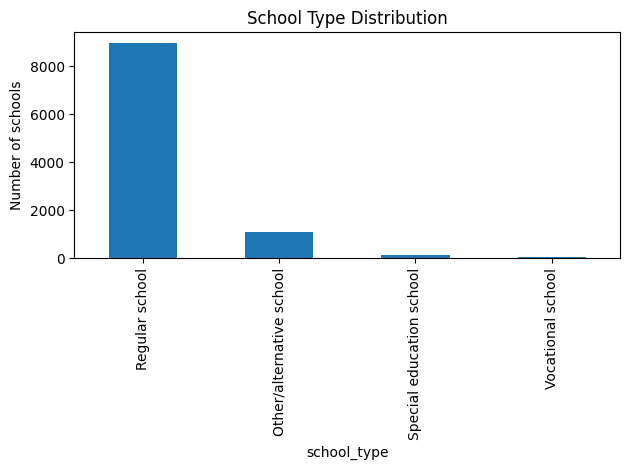

In [35]:
df['school_type'].value_counts(dropna=False).plot(kind='bar')
plt.title('School Type Distribution')
plt.ylabel('Number of schools')
plt.tight_layout()
plt.show()

**Observation**
- This dataset is dominated by regular schools types
- Right skewed
- The least amount of schools in the dataset are vocational schools, then special education schools

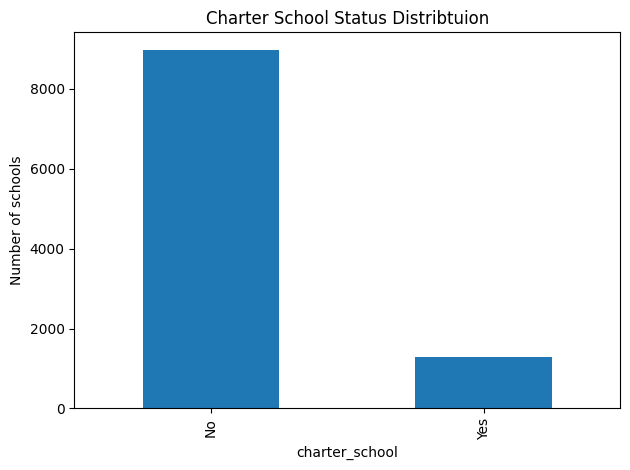

In [36]:
df['charter_school'].value_counts(dropna=False).plot(kind='bar')
plt.title('Charter School Status Distribtuion')
plt.ylabel('Number of schools')
plt.tight_layout()
plt.show()

**Observation** 
- There's a lot more schools that aren't charter schools in the dataset
- This means it's mainly public, regular schools

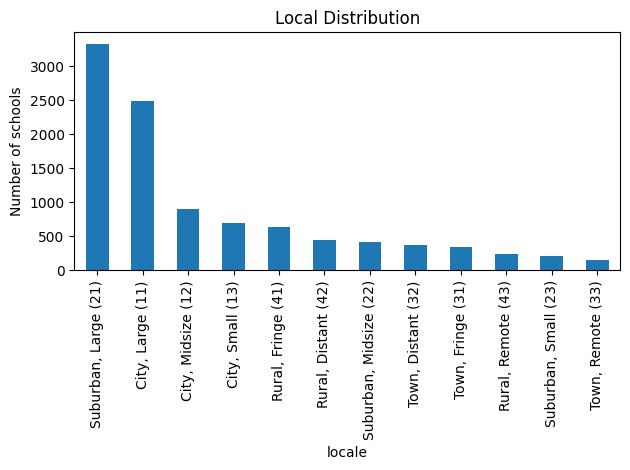

In [37]:
df['locale'].value_counts(dropna=False).plot(kind='bar')
plt.title('Local Distribution')
plt.ylabel('Number of schools')
plt.tight_layout()
plt.show()

**Observation**
- Right skewed since the tail goes to the right
- The majority of schools are in a large suburban area

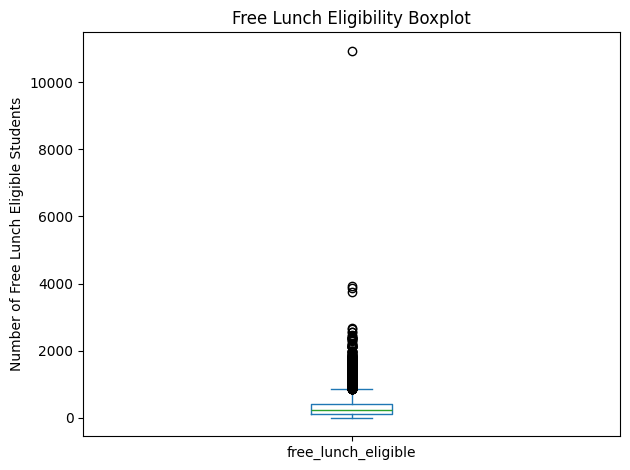

In [38]:
df['free_lunch_eligible'].dropna().plot(kind='box')
plt.title('Free Lunch Eligibility Boxplot')
plt.ylabel('Number of Free Lunch Eligible Students')
plt.tight_layout()
plt.show()

**Observation**
- There are a few outliers, but one major outlier has over 10,000 free lunch eligible students.
- That outlier is probably an error

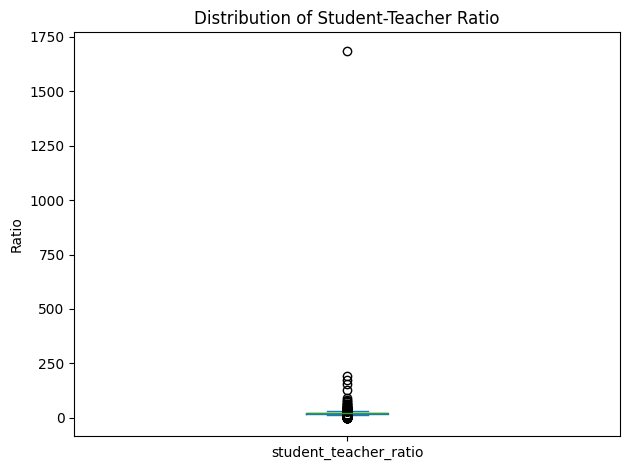

In [39]:
df['student_teacher_ratio'].dropna().plot(kind='box')
plt.title('Distribution of Student-Teacher Ratio')
plt.ylabel('Ratio')
plt.tight_layout()
plt.show()

**Observation**
- There's the an outlier where there's under 1750 students per teacher
- Possibly the same school that is causing the outlier in Free Lunch Eligibility Boxplot

**5.7 Bivariate Analysis**

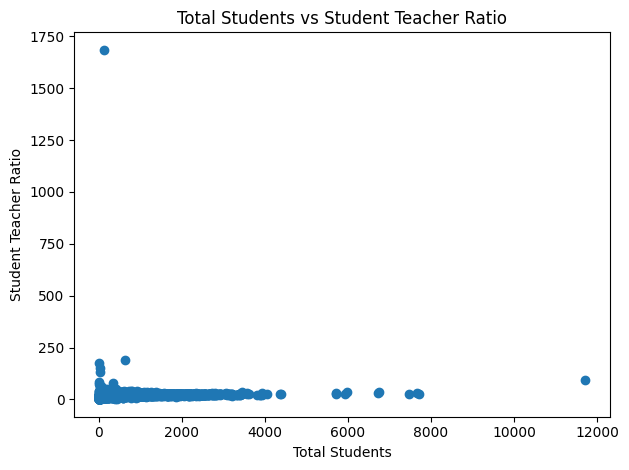

In [40]:
plt.scatter(df['total_students_detail'], df['student_teacher_ratio'])
plt.title('Total Students vs Student Teacher Ratio')
plt.xlabel('Total Students')
plt.ylabel('Student Teacher Ratio')
plt.tight_layout()
plt.show()

**Observation**
- There's a positive relationship between the number of students in a school and the student teacher ratio
- As the number of students increases, the ratio increases

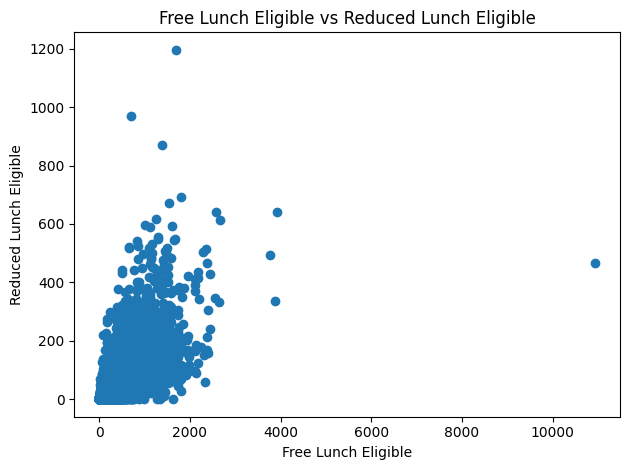

In [41]:
plt.scatter(df['free_lunch_eligible'], df['reduced_lunch_eligible'])
plt.title('Free Lunch Eligible vs Reduced Lunch Eligible')
plt.xlabel('Free Lunch Eligible')
plt.ylabel('Reduced Lunch Eligible')
plt.tight_layout()
plt.show()

**Observation**
- There's a positive relationship between reduced_lunch_eligible and free_lunch_eligible

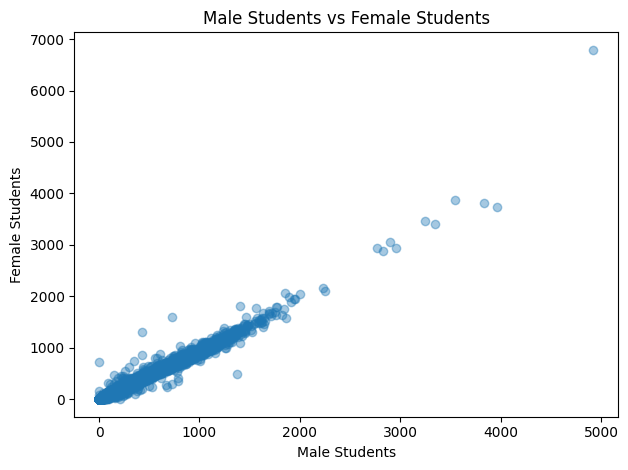

In [42]:
plt.scatter(df['male_students'], df['female_students'], alpha=0.4)
plt.title('Male Students vs Female Students')
plt.xlabel('Male Students')
plt.ylabel('Female Students')
plt.tight_layout()
plt.show()

**Observation**
- There's a strong positive relationship between male and female students

**5.8 Multivariate Analysis**
- Add Hassan's code here

**5.9 EDA Summary**

- schools_detailed was first investigated by looking at its attributes, like shape, column names, data types 
- The dataset was cleaned by dropping unnecessary columns, replacing symbols with NaN, and removing duplicate schools
- Numeric columns that were originally object data types were turned into a numeric data type
- After cleaning schools_detailed, we were left with 10254 records
- For Univariate Analysis, bar charts were made for school_type, charter_school, and locale. This showed that the majority of schools in our dataset are regular schools, are not a charter school, and reside in a suburban area. A boxplot was also made for free_lunch_eligible and student_teacher_ratio, which revealed that there are a lot of outliers within this dataset for free_lunch_eligible and student_teacher_ratio. 
- For Bivariate Analysis, scatter plots were made for total_students_detail vs student_teacher_ratio, free_lunch_eligible vs reduced_lunch_eligible, and male_students vs female_students. For all plots, they showed a positive relationship as one variable increased, the other variable tended to increase as well. male_students vs female_students showed the strongest correlation, as it looks like a linear relationship.
- For Multivariate Analysis:
    **ADD HASSAN'S STUFF HERE**
- Add correlation and skewness info

**6.0 Data Visualization?**

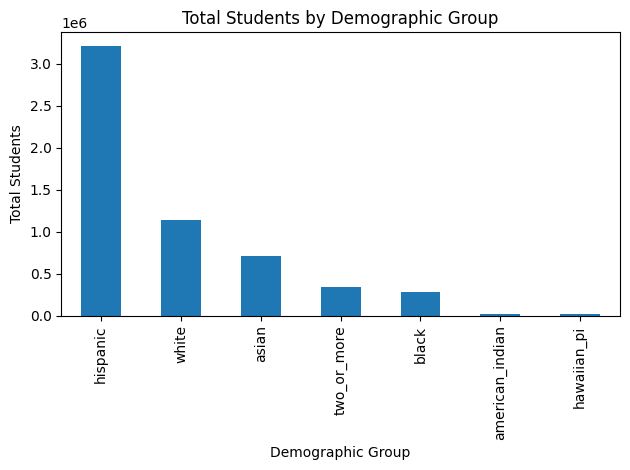

In [43]:
demographic_totals = df[['american_indian', 'asian', 'black', 'hispanic', 'white', 'hawaiian_pi', 'two_or_more']].sum().sort_values(ascending=False)
demographic_totals.plot(kind='bar')
plt.title('Total Students by Demographic Group')
plt.xlabel('Demographic Group')
plt.ylabel('Total Students')
plt.tight_layout()
plt.show()

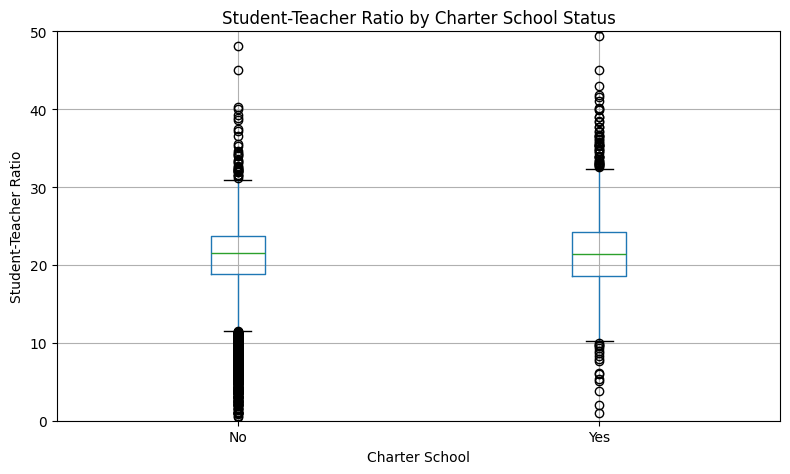

In [51]:
df.boxplot(column='student_teacher_ratio', by='charter_school', figsize=(8,5))
plt.title('Student-Teacher Ratio by Charter School Status')
plt.suptitle('')
plt.xlabel('Charter School')
plt.ylabel('Student-Teacher Ratio')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

**7.0 Data Mining Questions**

**7.1 Which demographic groups are the most present across schools?** 
- Hispanic, white and asian are the most represented demographic groups across schools in California
- The least represented groups are black, american_indian, and hawaiian_pi

**7.2 What is the relationship between free lunch eligibility and reduced lunch eligibility?**
- The scatter plot earlier showed a positive relationship between free_lunch_eligibile and reduced_lunch_eligible
- Schools that have a high number of free lunch eligible students tend to also have a high number of reduced lunch eligible students as well

**7.3 Which locale category contains the most schools?**
- The bar chart showed that the most schools in this dataset were in large, suburban areas
- Remote towns had the least amount of schools in this dataset

**7.4 How does student-teacher ratio differ by charter school status?**
- The boxplot shows that charter schools and non-charter schools have similar student-teacher ratios
- However, charter schools' median is slightly higher for student-teacher ratios
- Charter school's middle 50% range is also a little higher
- The differences are very minimal though, and show that charter schools and non-charter schools have comparable student-teacher ratios